# 02 — Smoke-train the model

Single-GPU training on a small subset for a handful of epochs. This is **not** how the paper's
models were trained — those used 12× V100s for 300 epochs (see `internal/slurm/train/`). The goal
of this notebook is to verify the full training loop runs on your machine and to give you a
starting template.

Three loss configurations match the paper:

| Run | `--lambda-residual` | `--lambda-phase` |
|---|---|---|
| FM only | 0 | 0 |
| FM + phase | 0 | 0.1 |
| FM + phase + residual | 1.0 | 0.1 |

We pick the third (the strongest) for the demo.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path('..').resolve()
MODEL_DIR = REPO_ROOT / 'Model'
if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

DATA_ROOT  = REPO_ROOT / 'Data'   # parent dir; contains one or more sweep subfolders
SWEEP_NAME = 'unified_sweep_mmi_ybranch_dc_7500_each_1p55um'
CKPT_DIR   = REPO_ROOT / 'checkpoints' / 'demo'
CKPT_DIR.mkdir(parents=True, exist_ok=True)
print('data root:', DATA_ROOT, '(exists)' if DATA_ROOT.is_dir() else '(MISSING)')
print('sweep:', SWEEP_NAME, '(exists)' if (DATA_ROOT / SWEEP_NAME / 'shards').is_dir() else '(MISSING)')
print('ckpts will go to:', CKPT_DIR)

data root: C:\Users\Joseph\Desktop\rayfield_test\PIC-Flow\Data (exists)
sweep: unified_sweep_mmi_ybranch_dc_7500_each_1p55um (exists)
ckpts will go to: C:\Users\Joseph\Desktop\rayfield_test\PIC-Flow\checkpoints\demo


## Launch via CLI

`Model/train.py` is the canonical entry point. The cell below builds the command for a 5-epoch
smoke run on whatever data is in `DATA_ROOT`.

In [2]:
cmd = [
    sys.executable, str(MODEL_DIR / 'train.py'),
    '--data-root', str(DATA_ROOT),
    '--include-sweeps', SWEEP_NAME,
    '--use-shards',
    # Architecture matching the released phase_residual_300.pt (~63 M params).
    # train.py defaults (hidden=128, blocks=2) build a different ~247 M model.
    '--hidden-size', '56',
    '--num-res-blocks', '3',
    '--attn-resolutions', '4,8',
    '--epochs', '1',
    '--phaseA-epochs', '1',
    '--phaseB-epochs', '0',
    '--batch-size', '2',
    '--train-num-workers', '0',
    '--val-num-workers', '0',
    '--subset-train-per-sweep', f'{SWEEP_NAME}=8',
    '--subset-val-per-sweep',   f'{SWEEP_NAME}=4',
    '--lr', '1e-4',
    '--lambda-residual', '0',
    '--lambda-phase', '0',
    '--ckpt-every', '1',
    '--eval-every', '1',
    '--log-every', '1',
    '--no-amp',
    '--no-compile',     # Triton/torch.compile not available on Windows
    '--no-use-wandb',
]
print(' \\\n  '.join(cmd))

C:\Users\Joseph\miniconda3\envs\testpicflow\python.exe \
  C:\Users\Joseph\Desktop\rayfield_test\PIC-Flow\Model\train.py \
  --data-root \
  C:\Users\Joseph\Desktop\rayfield_test\PIC-Flow\Data \
  --include-sweeps \
  unified_sweep_mmi_ybranch_dc_7500_each_1p55um \
  --use-shards \
  --hidden-size \
  56 \
  --num-res-blocks \
  3 \
  --attn-resolutions \
  4,8 \
  --epochs \
  1 \
  --phaseA-epochs \
  1 \
  --phaseB-epochs \
  0 \
  --batch-size \
  2 \
  --train-num-workers \
  0 \
  --val-num-workers \
  0 \
  --subset-train-per-sweep \
  unified_sweep_mmi_ybranch_dc_7500_each_1p55um=8 \
  --subset-val-per-sweep \
  unified_sweep_mmi_ybranch_dc_7500_each_1p55um=4 \
  --lr \
  1e-4 \
  --lambda-residual \
  0 \
  --lambda-phase \
  0 \
  --ckpt-every \
  1 \
  --eval-every \
  1 \
  --log-every \
  1 \
  --no-amp \
  --no-compile \
  --no-use-wandb


In [3]:
import subprocess
result = subprocess.run(cmd, cwd=str(REPO_ROOT))
print('exit code:', result.returncode)
assert result.returncode == 0, 'training failed'

exit code: 0


## Loss curves

`train.py` writes a `history.json` per run. Read and plot it once training finishes.

logged epochs: [1]


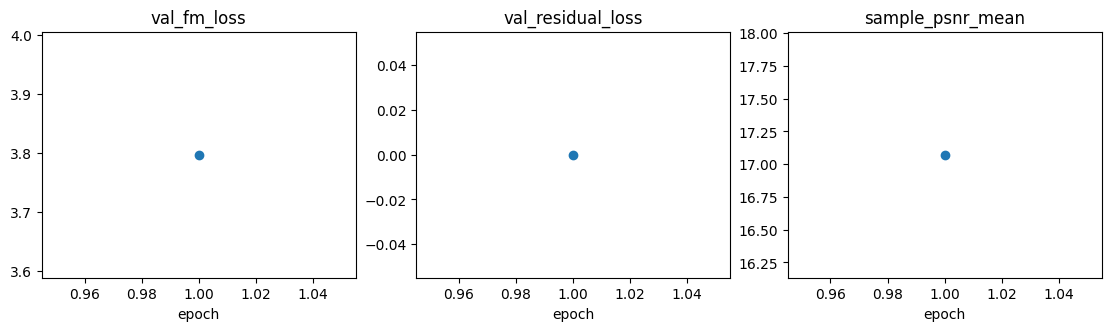

In [4]:
import csv
from pathlib import Path
import matplotlib.pyplot as plt

LOG_DIR = REPO_ROOT / 'logs_physics_unet_pbfm' / 'physics_unet_pbfm_ddp'
val_csv = LOG_DIR / 'validation.csv'
if not val_csv.is_file():
    print('No validation.csv yet — run the training cell first. Looked in:', val_csv)
else:
    rows = list(csv.DictReader(val_csv.open()))
    epochs = [int(r['epoch']) for r in rows]
    print(f'logged epochs: {epochs}')
    keys = ('val_fm_loss', 'val_residual_loss', 'sample_psnr_mean')
    fig, ax = plt.subplots(1, len(keys), figsize=(11, 3.2), constrained_layout=True)
    for a, key in zip(ax, keys):
        ys = [float(r[key]) for r in rows if r.get(key)]
        if ys:
            a.plot(epochs[:len(ys)], ys, marker='o')
        a.set_xlabel('epoch'); a.set_title(key)
    plt.show()

After a checkpoint is written, jump to [`03_inference.ipynb`](03_inference.ipynb) to evaluate it.